# Physical Track Analysis — SLSNe Detection with Rubin LSST

Parallel to `analysis_multimodel_comparison.ipynb` (GP track).
Physical templates use MOSFiT posteriors (Gómez+2024), full SED synthesis via `synthesize_mag_at_z()`. Valid z=0.1–5.0.

GP canonical runs (260409) are untouched by this notebook.

**Reload flags:** Templates NO — Population NO — Mag grid NO (not used in physical path)

In [ ]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import healpy as hp
from pathlib import Path
from importlib import reload

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_rate_vs_redshift,
    plot_healpix_efficiency,
)

# --- Configuration ---
MODELS = [
    'naive_physical',
    'o_dependent_physical',
    'fe_dependent_physical',
]
CADENCES = [
    'baseline_v5.1.1_10yrs',
    'baseline_v5.3.0_10yrs',
    'noroll_v5.0.0_10yrs',
    'poor_weather_v5.0.1_10yrs',
]
SURVEY_YEARS = 10
Z_MIN, Z_MAX = 0.1, 5.0

# --- Paths ---
SHARED_DIR   = get_shared_output_dir('SLSNe')
ADAPTIVE_DIR = REPO / 'output/SLSNe/adaptive'

# --- Load adaptive efficiency results ---
# Each model has one adaptive_results.csv with columns:
#   z_lo, z_hi, cadence, metric, n_events, n_success, efficiency, sigma
print('=== Adaptive Results Check ===')
ADAPTIVE = {}
for model in MODELS:
    csv = ADAPTIVE_DIR / f'{model}_adaptive_results.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        ADAPTIVE[model] = df
        zmax = df['z_hi'].max()
        n_bins = df['z_hi'].nunique()
        print(f'  OK  {model}: {n_bins} z-bins, z_max={zmax:.1f}')
    else:
        print(f'  MISSING  {model}: {csv}')

print(f'\nLoaded {len(ADAPTIVE)}/{len(MODELS)} adaptive result files')
#

✓ Saved rate evolution plot → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_evolution_comparison_260409.png


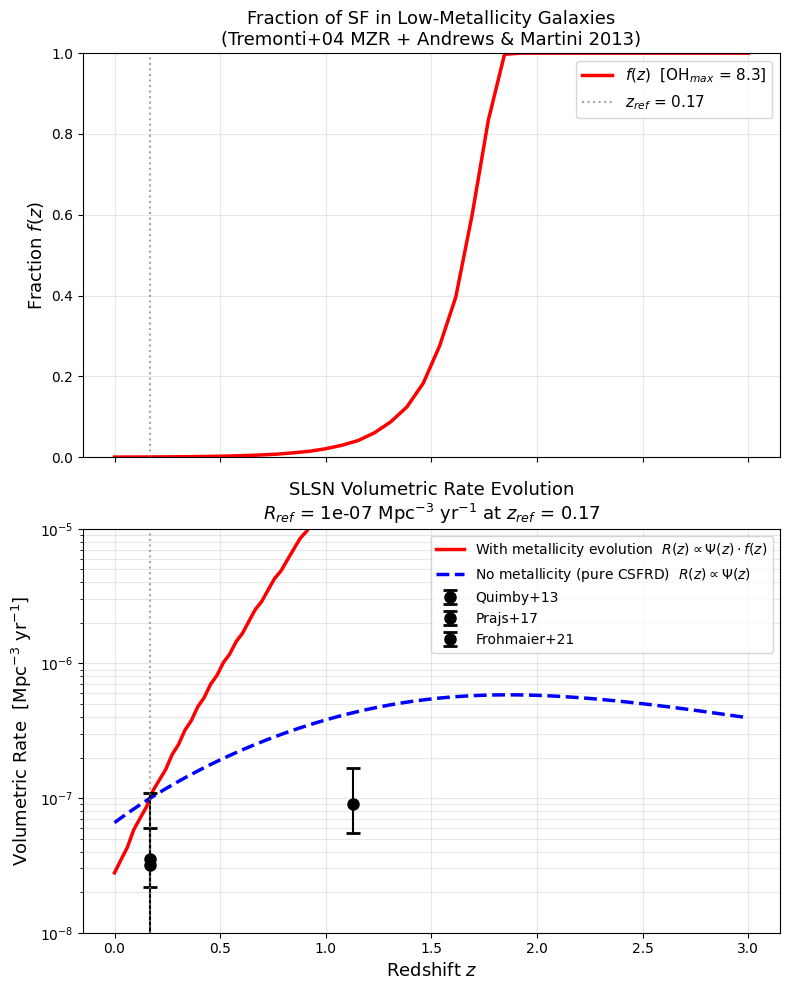

Saved: rate_evolution_comparison_260409.png


In [3]:
# ============================================================================
# CELL A: Rate evolution comparison — analytical R(z) curves (model-agnostic)
# Shows SFR x metallicity fraction vs pure-SFR curve + observed measurements.
# No population needed — call once for all models.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_rate_evolution_comparison

out_rate_fig = get_output_dir('SLSNe') / 'rate_evolution_comparison_physical.png'
plot_rate_evolution_comparison(save_path=out_rate_fig)
print(f'Saved: {out_rate_fig.name}')


In [ ]:
# ============================================================================
# CELL 6: Build per-model efficiency data from adaptive results CSV
# No population pkl or .npy loading needed — adaptive CSV has everything.
# Builds pop_data dict compatible with downstream plotting cells.
# ============================================================================

METRIC_MAP = {
    'detect':       'SLSN_Detect_Physical_Metric',
    'characterize': 'SLSN_Characterize_Physical_Metric',
    'villar':       'SLSN_Villar_Physical_Metric',
    'elasticc':     'SLSN_ELAsTiCC_Metric',
    'spectrigger':  'SLSN_SpecTrigger_Physical_Metric',
}
METRIC_KEYS = list(METRIC_MAP.keys())

pop_data = {}

for model in MODELS:
    if model not in ADAPTIVE:
        print(f'Skipping {model} — no adaptive results')
        continue

    df = ADAPTIVE[model]
    print(f'\n{model}:')

    # Per-cadence per-metric efficiency by z-bin
    metric_arrays = {m: {} for m in METRIC_KEYS}
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    for short, full in METRIC_MAP.items():
        for cadence in CADENCES:
            sub = df[(df['metric']==full) & (df['cadence']==cadence)]
            if sub.empty:
                metric_arrays[short][cadence] = None
                continue
            # Build arrays indexed by z-bin: efficiency and n_events
            eff   = sub.set_index(['z_lo','z_hi'])['efficiency']
            n_ev  = sub.set_index(['z_lo','z_hi'])['n_events']
            metric_arrays[short][cadence] = {
                'z_bins':    [(r[0],r[1]) for r in z_bins],
                'efficiency': [float(eff.get((z0,z1), np.nan)) for z0,z1 in z_bins],
                'n_events':   [int(n_ev.get((z0,z1), 0)) for z0,z1 in z_bins],
            }

    # Z-bin centers for plotting
    z_lo_arr  = np.array([b[0] for b in z_bins])
    z_hi_arr  = np.array([b[1] for b in z_bins])
    z_centers = 0.5 * (z_lo_arr + z_hi_arr)

    pop_data[model] = {
        'z_bins':    z_bins,
        'z_lo':      z_lo_arr,
        'z_hi':      z_hi_arr,
        'z_centers': z_centers,
        'detect':       metric_arrays['detect'],
        'characterize': metric_arrays['characterize'],
        'spectrigger':  metric_arrays['spectrigger'],
        'villar':       metric_arrays['villar'],
        'elasticc':     metric_arrays['elasticc'],
    }
    print(f'  z-bins: {len(z_bins)}, cadences with data: {CADENCES}')

print('\n=== Adaptive efficiency data loaded for all models ===')



=== Population diagnostics: fe_dependent ===
[LOAD] Loaded 2243377 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent.pkl


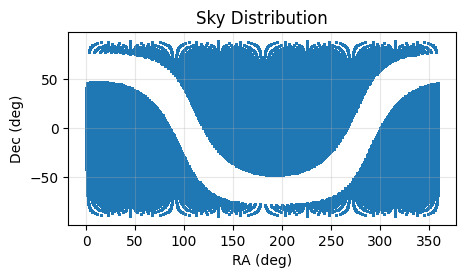

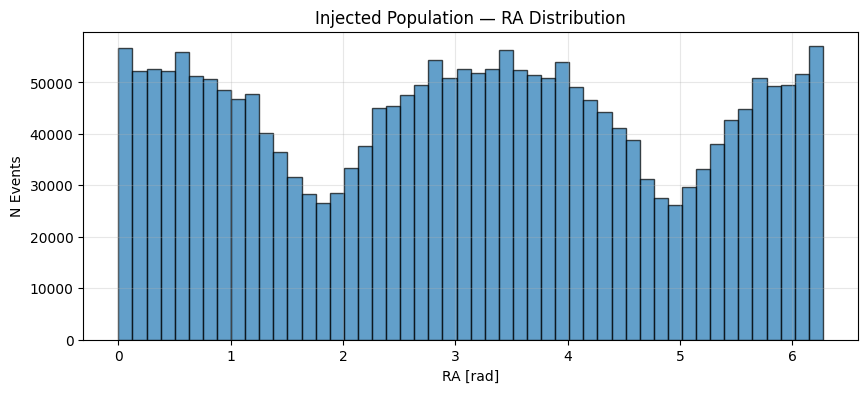

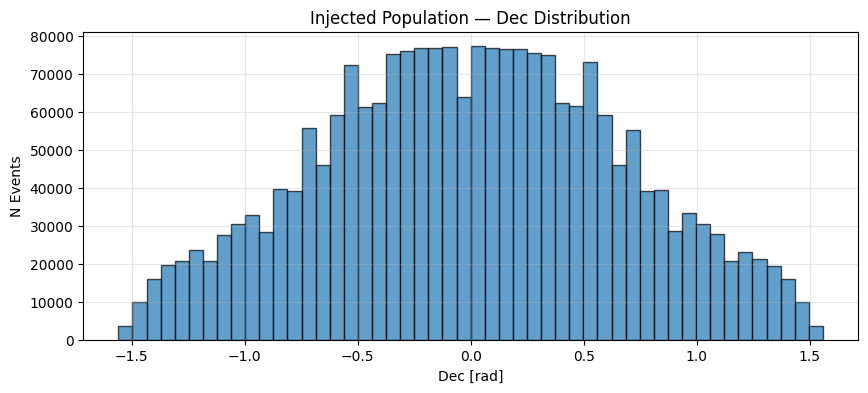

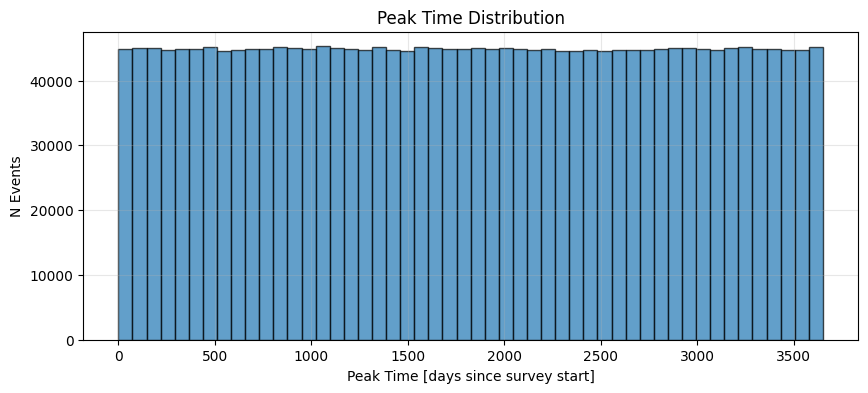

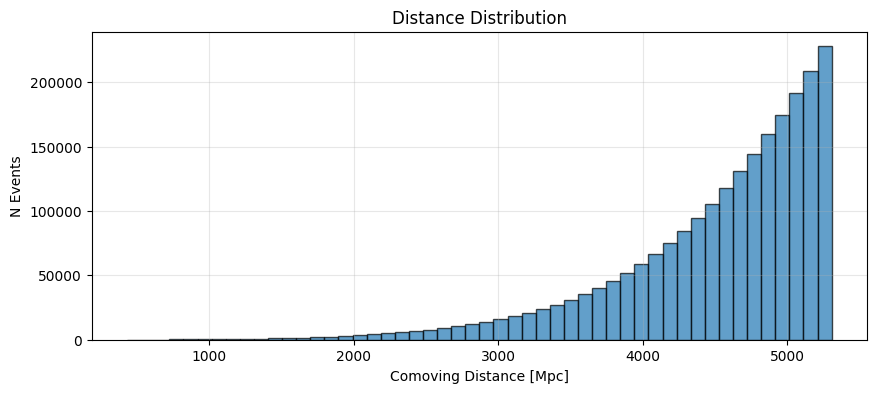

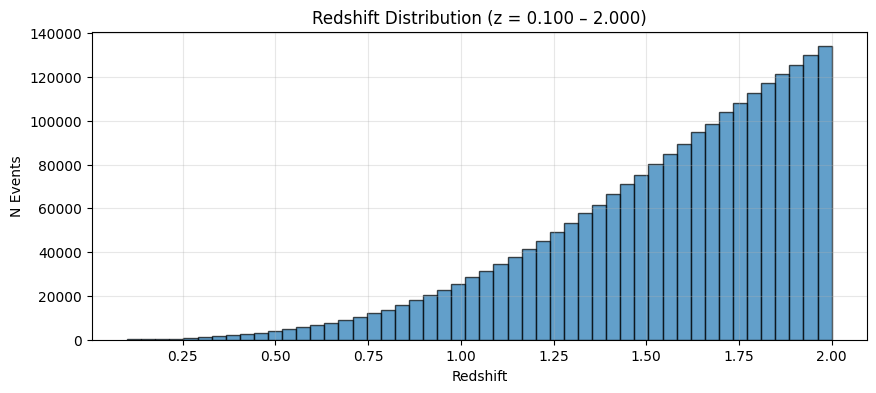

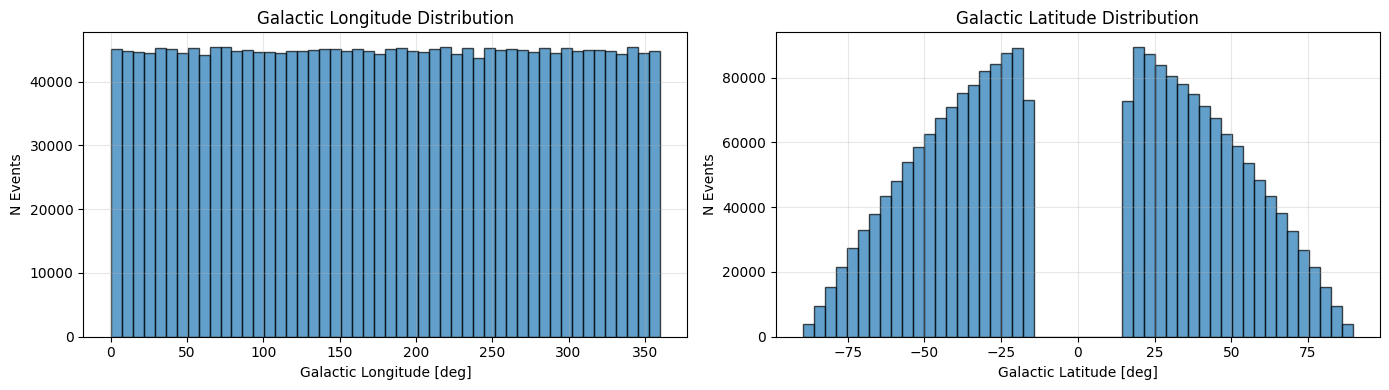

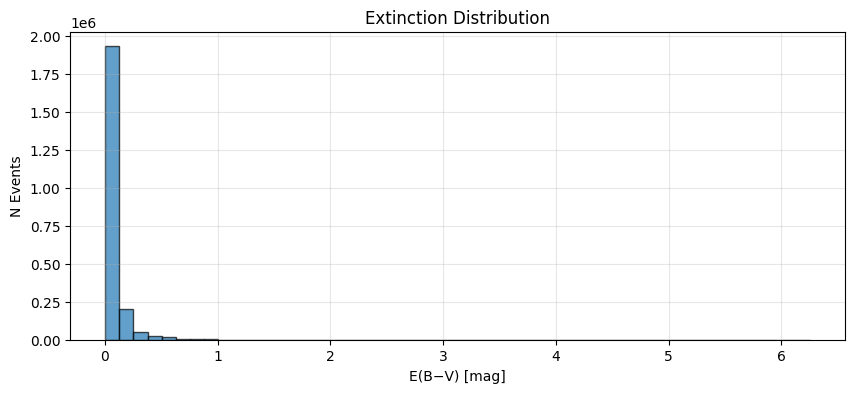


=== Population diagnostics: o_dependent ===
[LOAD] Loaded 1146435 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_o_dependent.pkl


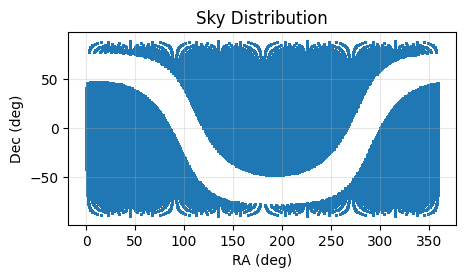

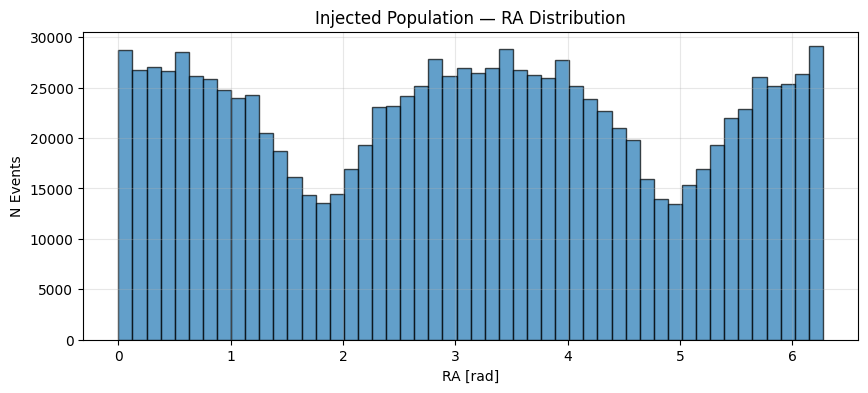

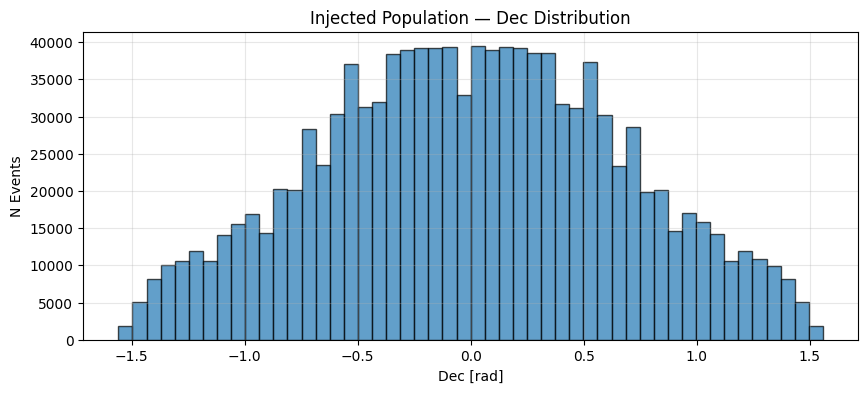

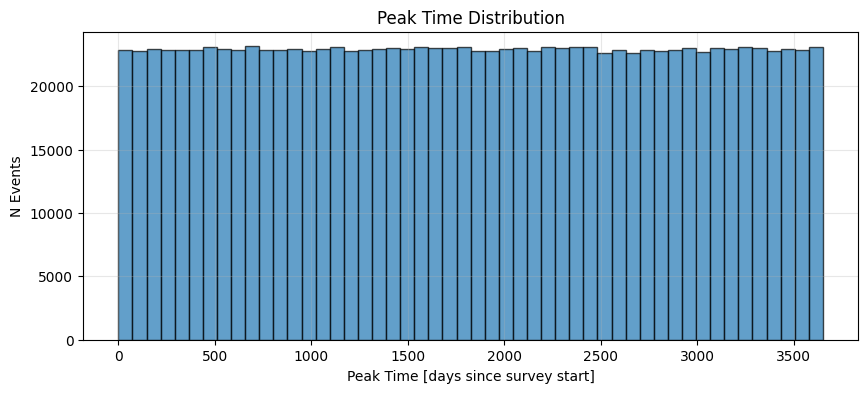

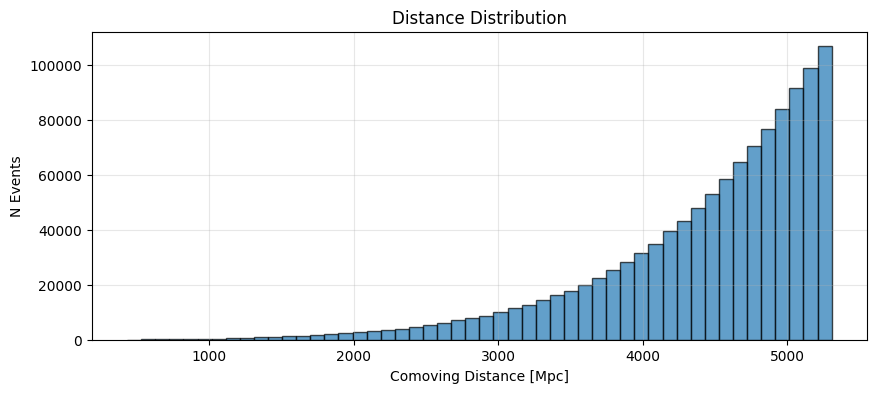

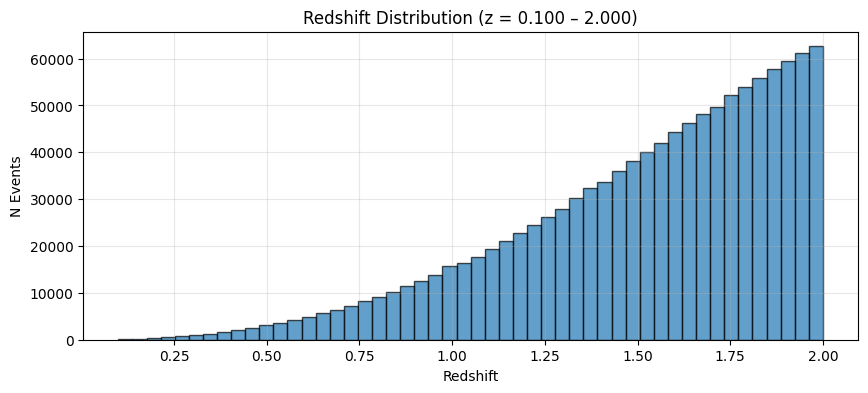

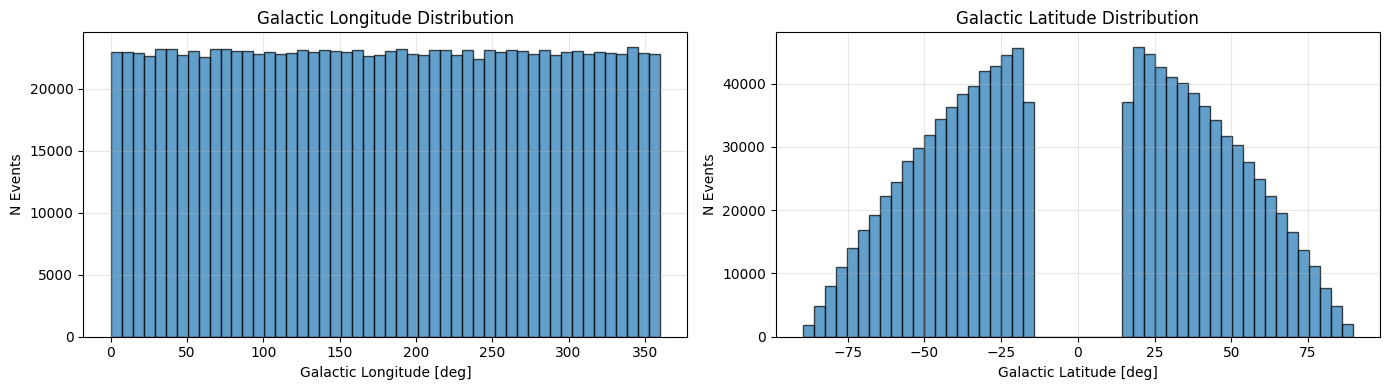

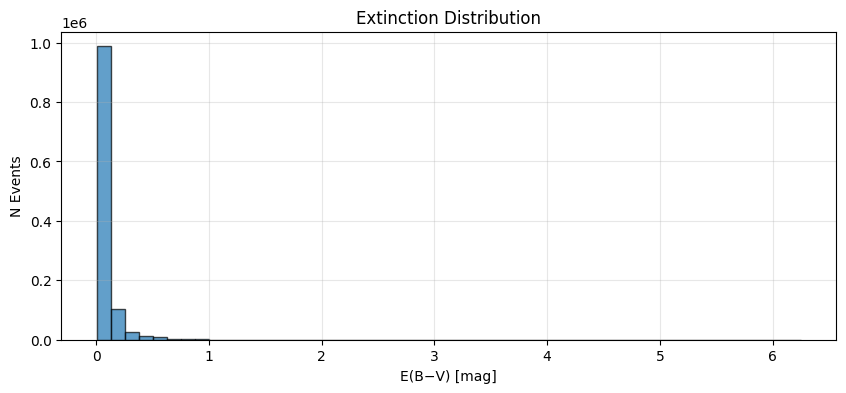


=== Population diagnostics: naive ===
[LOAD] Loaded 750598 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_naive.pkl


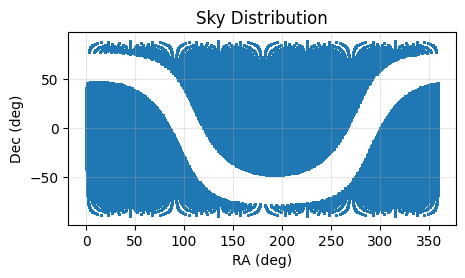

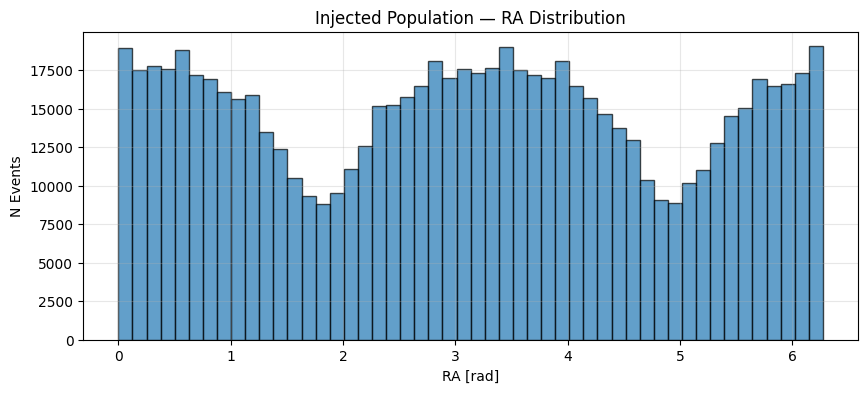

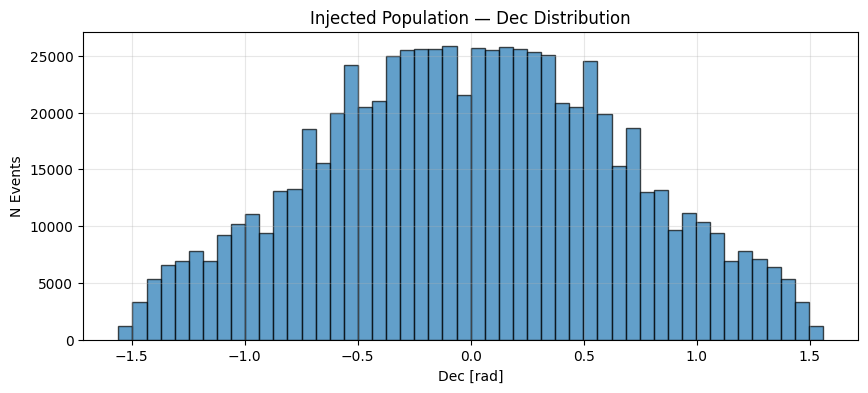

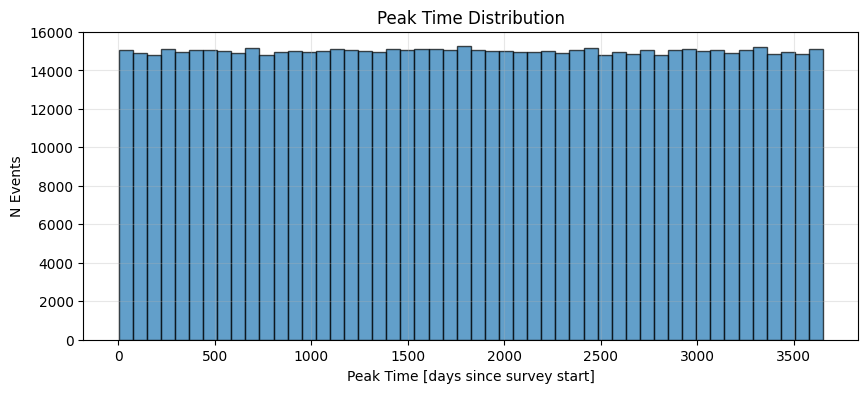

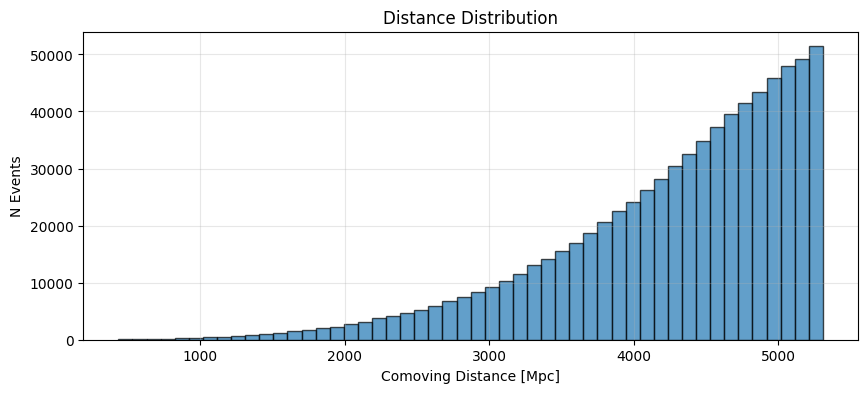

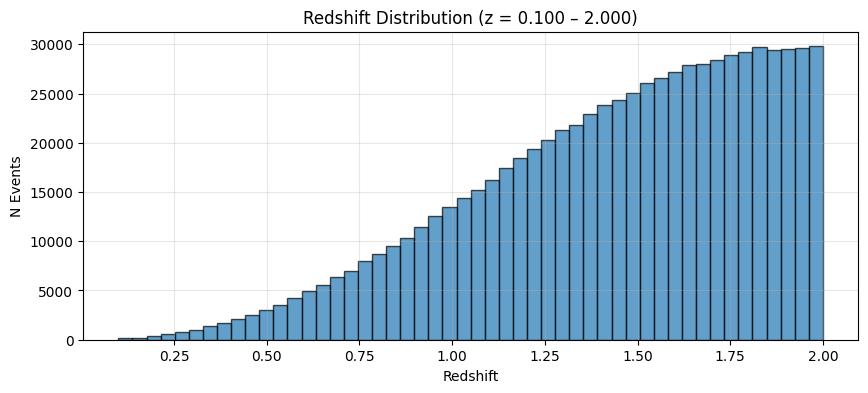

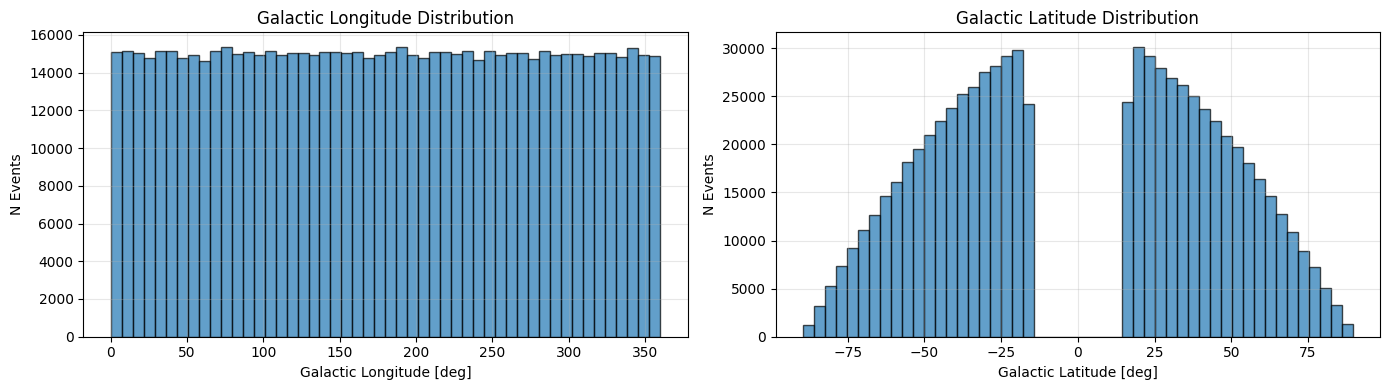

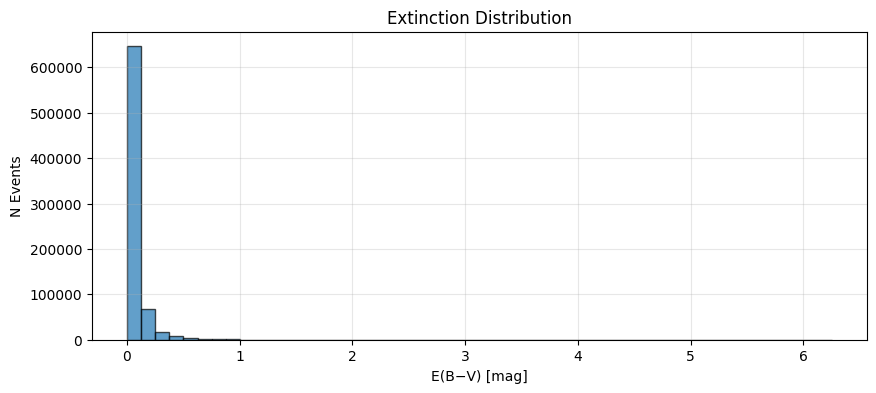

In [5]:
# ============================================================================
# CELL B: Population diagnostics — all 3 models
# plot_population_diagnostics needs distances_mpc, ebv, gall, galb which are
# not in pop_data — reload the slicer for each model.
# Also stores pop_slicers dict so Cells C and D can reuse without reloading.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_diagnostics

pop_slicers = {}

for model in MODELS:
    print(f'\n=== Population diagnostics: {model} ===')
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    pop = generate_SLSN_PopSlicer(
        lc_model=templates,
        load_from=str(pop_pkl),
        make_debug_plots=False
    )
    pop_slicers[model] = pop          # cache for Cells C and D
    sp = pop.slice_points

    plot_population_diagnostics(
        ra_rad        = sp['ra'],
        dec_rad       = sp['dec'],
        peak_times    = sp['peak_time'],
        distances_mpc = sp['distance'],
        z_vals        = sp['z'],
        ebv           = sp.get('ebv', None),
        gall          = sp.get('gall', None),
        galb          = sp.get('galb', None),
        outdir        = str(model_dir),
        prefix        = f'population_{model}'
    )


In [6]:
# ============================================================================
# CELL 2: Load all 3 summary CSVs into one combined DataFrame
# Each CSV has columns: cadence, metric, n_events, n_success, efficiency
# We add a 'model' column and compute 'per_year'
# ============================================================================
rows = []
for model, csv_path in SUMMARY_FILES.items():
    df_s = pd.read_csv(csv_path)
    df_s['model']    = model
    df_s['per_year'] = df_s['n_success'] / SURVEY_YEARS
    rows.append(df_s)

df_all = pd.concat(rows, ignore_index=True)

# Clean up cadence names for display (strip version/10yrs suffix)
cadence_labels = {
    'baseline_v5.1.1_10yrs':    'baseline',
    'four_roll_v5.0.0_10yrs':   'four_roll',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor_weather',
    'baseline_v5.3.0_10yrs':     'Baseline v5.3.0',
}
df_all['cadence_short'] = df_all['cadence'].map(cadence_labels)

model_labels = {
    'fe_dependent': 'Fe-dependent',
    'o_dependent':  'O-dependent',
    'naive':        'Naive SFR',
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}
df_all['model_label'] = df_all['model'].map(model_labels)

print(f'Loaded {len(df_all)} rows across {df_all["model"].nunique()} models')
print(f'Metrics present: {df_all["metric"].unique().tolist()}')

Loaded 60 rows across 3 models
Metrics present: ['SLSN_Detect_Metric', 'SLSN_CharacterizeMetric', 'SLSN_VillarMetric', 'SLSN_ELAsTiCC_Metric', 'SLSN_SpecTriggerMetric']


In [7]:
# ============================================================================
# CELL 3: Summary table — detections/yr and efficiency, all 12 combinations
# Primary reference table for the paper / collaborator email
# ============================================================================

detect_df = df_all[df_all['metric'] == 'SLSN_Detect_Metric'].copy()
char_df   = df_all[df_all['metric'] == 'SLSN_CharacterizeMetric'].copy()
spec_df   = df_all[df_all['metric'] == 'SLSN_SpecTriggerMetric'].copy()
villar_df = df_all[df_all['metric'] == 'SLSN_VillarMetric'].copy()
elasticc_df = df_all[df_all['metric'] =='SLSN_ELAsTiCC_Metric'].copy()

# Detections per year — pivot: rows=model, columns=cadence
pivot_per_yr = detect_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

# Efficiency [%] pivot
pivot_eff = detect_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='efficiency', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']] * 100

# Population sizes for context
print('\n=== Population sizes (n_events) ===')
for model in MODELS:
    n = detect_df[detect_df['model'] == model]['n_events'].iloc[0]
    print(f'  {model:<15}: {n:>9,} events')

print('=== Detections per Year (Detect Metric) — 3 models × 4 cadences ===')
print(pivot_per_yr.round(0).to_string())

print('\n=== Detection Efficiency [%] ===')
print(pivot_eff.round(3).to_string())

# Characterize per year
char_pivot = char_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

print('\n=== Characterize per Year ===')
print(char_pivot.round(1).to_string())

# Spectrigger per year
spec_pivot = spec_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

print('\n=== Spec Trigger per Year (mag_limit=23.0) ===')
print(spec_pivot.round(1).to_string())

# Villar per year
villar_pivot = villar_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

print('\n=== Villar Metric per Year ===')
print(villar_pivot.round(1).to_string())

# ELAsTiCC per year
elasticc_pivot = elasticc_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

print('\n=== ELAsTiCC Metric per Year ===')
print(elasticc_pivot.round(1).to_string())



=== Population sizes (n_events) ===
  fe_dependent   : 2,243,377 events
  o_dependent    : 1,146,435 events
  naive          :   750,598 events
=== Detections per Year (Detect Metric) — 3 models × 4 cadences ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      642.0      638.0   730.0         488.0
Naive SFR         330.0      325.0   378.0         254.0
O-dependent       386.0      379.0   443.0         293.0

=== Detection Efficiency [%] ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      0.286      0.284   0.325         0.218
Naive SFR         0.440      0.433   0.504         0.338
O-dependent       0.337      0.331   0.386         0.256

=== Characterize per Year ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      230.6      239.0   2

In [8]:
# ============================================================================
# CELL C: Simulated vs observed rates — all 3 models
# Reuses pop_slicers cached by Cell B (no reload needed).
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import compare_simulated_vs_observed_rates

rate_tables = {}
for model in MODELS:
    print(f'\n{"="*65}')
    print(f'Model: {model_labels[model]}')
    df_rate = compare_simulated_vs_observed_rates(pop_slicers[model])
    rate_tables[model] = df_rate



Model: Fe-dependent

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      1235     3.25e+09        3.80e-08       3.20e-08       1.19e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01      5166     9.22e+09        5.61e-08            NaN            NaN         —
4.00e-01 7.00e-01 5.50e-01     41796     4.05e+10        1.03e-07            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01    133103     6.83e+10        1.95e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    649518     1.57e+11        4.14e-07       9.10e-08       4.55e+00  Prajs+17
1.50e+00 2.00e+00 1.75e+00   1412559     1.86e+11        7.61e-07            NaN            NaN         —


Model: O-dependent

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      

In [ ]:
# SED spot check — physical track only
# Verify synthesize_mag_at_z() produces sensible magnitudes
# at representative redshifts before trusting metric results.
# GP templates do not use this code path.

from slsn_metrics.model import synthesize_mag_at_z

test_redshifts = [0.3, 1.5, 3.0]
test_phase     = 50.0   # mid-range post-peak phase
test_filters   = ['g', 'r', 'i', 'z']
n_events_check = 5

print('SED spot check — apparent mags from synthesize_mag_at_z()')
print(f'{"event":>6} {"z":>5} {"filt":>5} {"mag":>8}')
print('-' * 32)
for ev_idx in range(n_events_check):
    sed_entry = templates.sed_grid[ev_idx]
    for z_test in test_redshifts:
        for filt in test_filters:
            m = synthesize_mag_at_z(sed_entry, test_phase, z_test, filt)
            status = f'{m:.3f}' if np.isfinite(m) else 'NaN'
            print(f'{ev_idx:>6} {z_test:>5.1f} {filt:>5} {status:>8}')

# Light curve plot at three redshifts for event 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
phases_plot = np.arange(1, 200, 5).astype(float)
filt_colors = {'g': 'blue', 'r': 'green', 'i': 'red', 'z': 'purple'}
for ax, z_test in zip(axes, test_redshifts):
    sed_entry = templates.sed_grid[0]
    for filt, col in filt_colors.items():
        mags_plot = np.array([synthesize_mag_at_z(sed_entry, ph, z_test, filt)
                              for ph in phases_plot])
        finite = np.isfinite(mags_plot)
        if finite.sum() > 0:
            ax.plot(phases_plot[finite], mags_plot[finite], color=col, label=filt)
    ax.invert_yaxis()
    ax.set_xlabel('Rest-frame phase (days)')
    ax.set_ylabel('Apparent mag (AB)')
    ax.set_title(f'z = {z_test}')
    ax.axhline(23.0, ls='--', color='gray', alpha=0.5, label='SpecTrigger')
    ax.legend(fontsize=8)
plt.suptitle('Physical SED spot check — Event 0')
plt.tight_layout()
plt.savefig(get_output_dir('SLSNe', subdir='physical_figures') / 'sed_spot_check.png', dpi=150)
plt.show()


In [ ]:
# ============================================================================
# CELL 7: Efficiency vs redshift — all 3 models x all cadences x all metrics
# Reads directly from adaptive results — full population per z-bin.
# ============================================================================

model_labels = {
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}
colors_model = {
    'naive_physical':        '#FF5722',
    'o_dependent_physical':  '#4CAF50',
    'fe_dependent_physical': '#2196F3',
}
metric_keys_z = ['elasticc', 'detect', 'characterize', 'villar', 'spectrigger']
ls_metric = {
    'detect':       '-',
    'characterize': '--',
    'spectrigger':  '-.',
    'villar':       ':',
    'elasticc':     (0, (5, 1)),
}
markers_metric = {
    'detect':       'o',
    'characterize': 's',
    'spectrigger':  '^',
    'villar':       'D',
    'elasticc':     'v',
}

for cadence in CADENCES:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for model in MODELS:
        if model not in pop_data:
            continue
        z_centers = pop_data[model]['z_centers']

        for metric in metric_keys_z:
            entry = pop_data[model][metric].get(cadence)
            if entry is None:
                continue
            eff_bins   = entry['efficiency']
            n_ev_bins  = entry['n_events']
            count_bins = [n / SURVEY_YEARS for n in n_ev_bins]

            label = f'{model_labels[model]} ({metric})'
            axes[0].plot(z_centers, eff_bins,
                         marker=markers_metric[metric],
                         color=colors_model[model],
                         ls=ls_metric[metric], lw=2, label=label)
            axes[1].plot(z_centers, count_bins,
                         marker=markers_metric[metric],
                         color=colors_model[model],
                         ls=ls_metric[metric], lw=2, label=label)

    for ax in axes:
        ax.set_xlabel('Redshift z', fontsize=12)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Detection efficiency', fontsize=12)
    axes[0].set_title(f'Efficiency vs z — {cadence}', fontsize=12)
    axes[1].set_ylabel('Events per year', fontsize=12)
    axes[1].set_title(f'Events/yr vs z — {cadence}', fontsize=12)

    plt.suptitle(f'Physical Track — {cadence}', fontsize=13, y=1.01)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'physical_eff_vs_z_{cadence}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()



--- fe_dependent x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_fe_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_baseline_v5.1.1_10yrs_260409.png


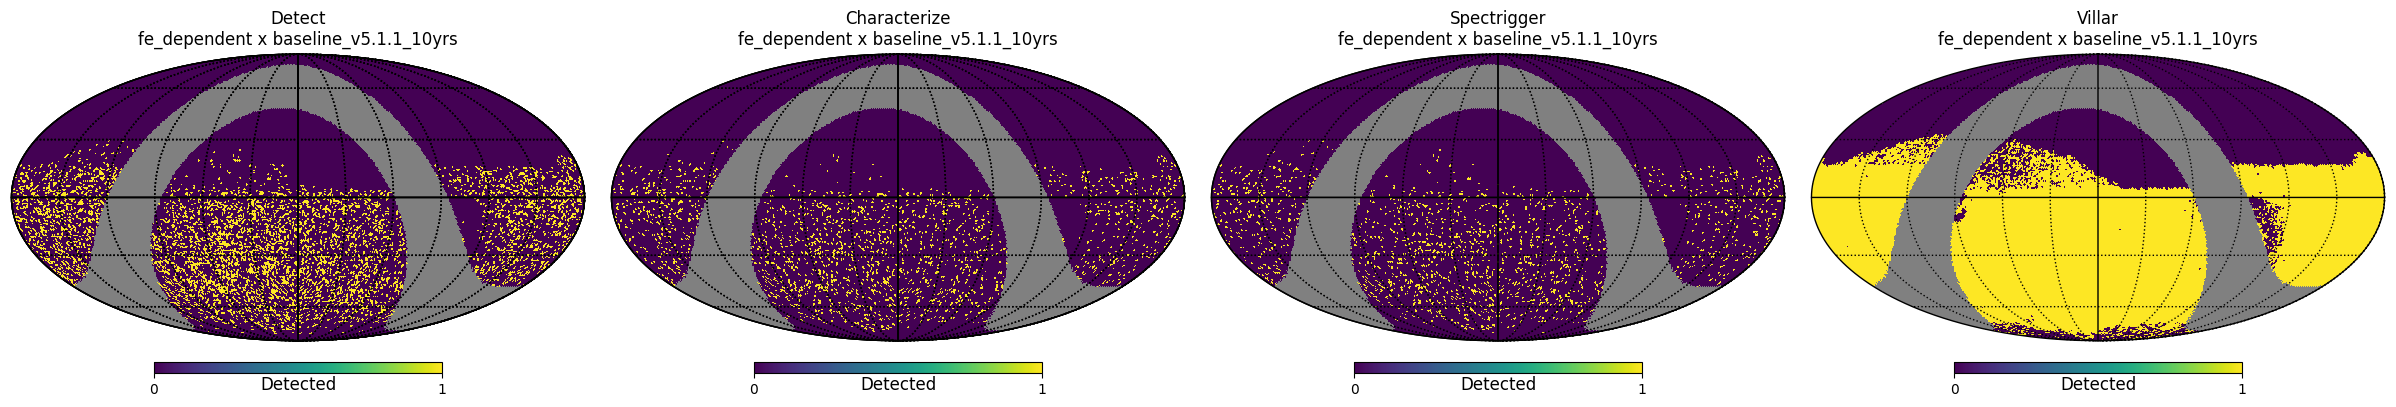

  Saved row: healpix_row_fe_dependent_baseline_v5.1.1_10yrs_260409.png

--- fe_dependent x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_fe_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_four_roll_v5.0.0_10yrs_260409.png


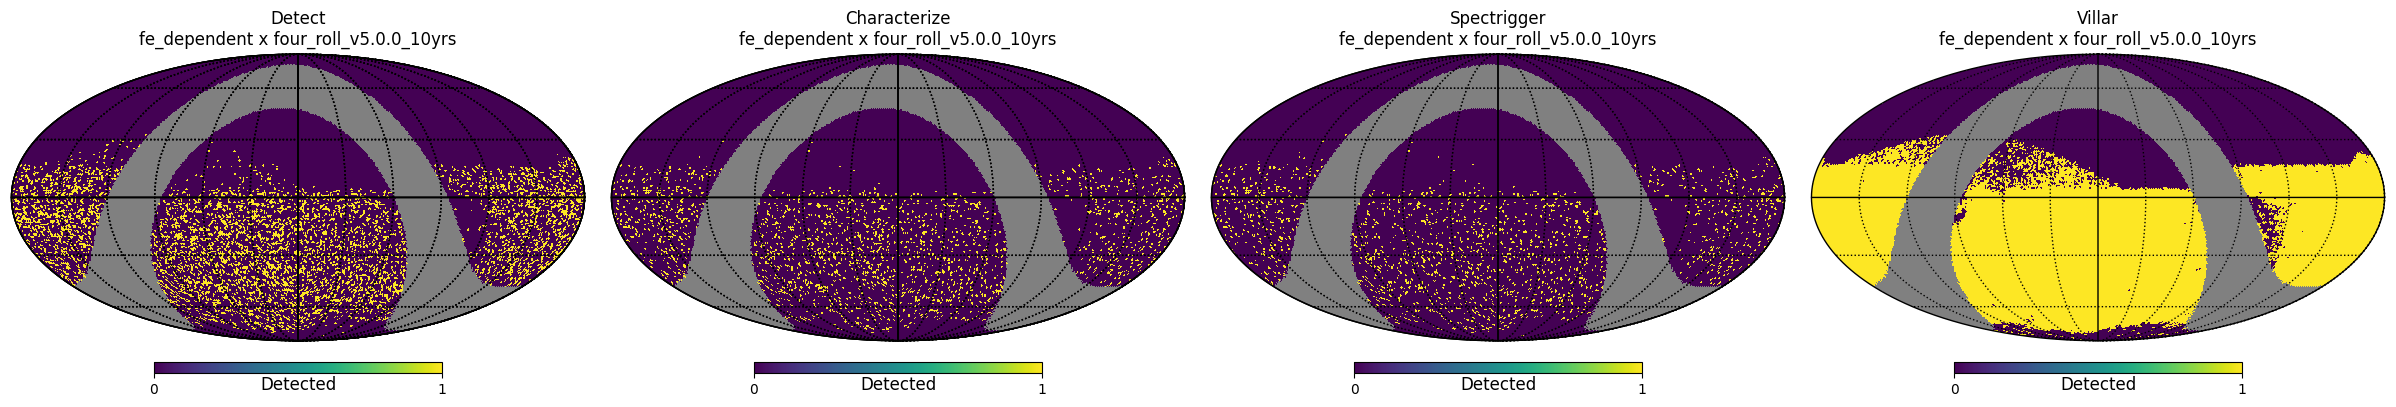

  Saved row: healpix_row_fe_dependent_four_roll_v5.0.0_10yrs_260409.png

--- fe_dependent x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_fe_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_noroll_v5.0.0_10yrs_260409.png


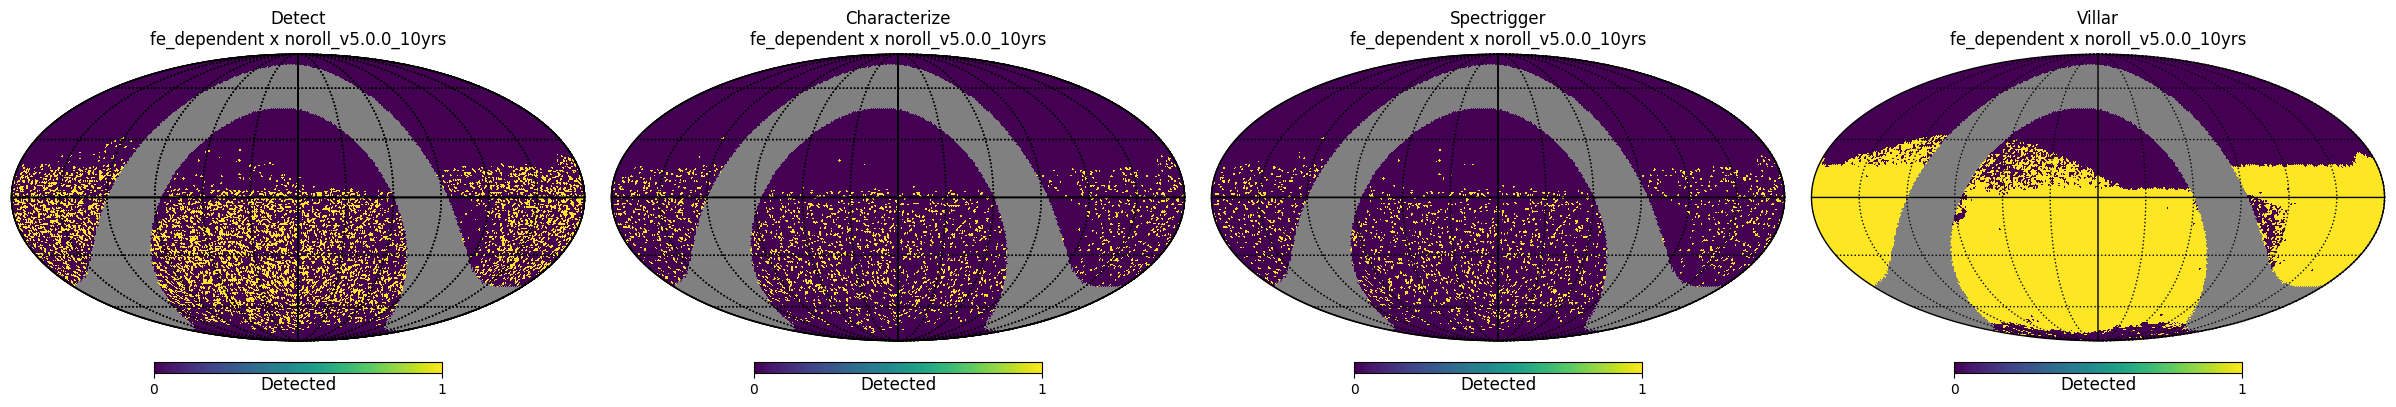

  Saved row: healpix_row_fe_dependent_noroll_v5.0.0_10yrs_260409.png

--- fe_dependent x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png


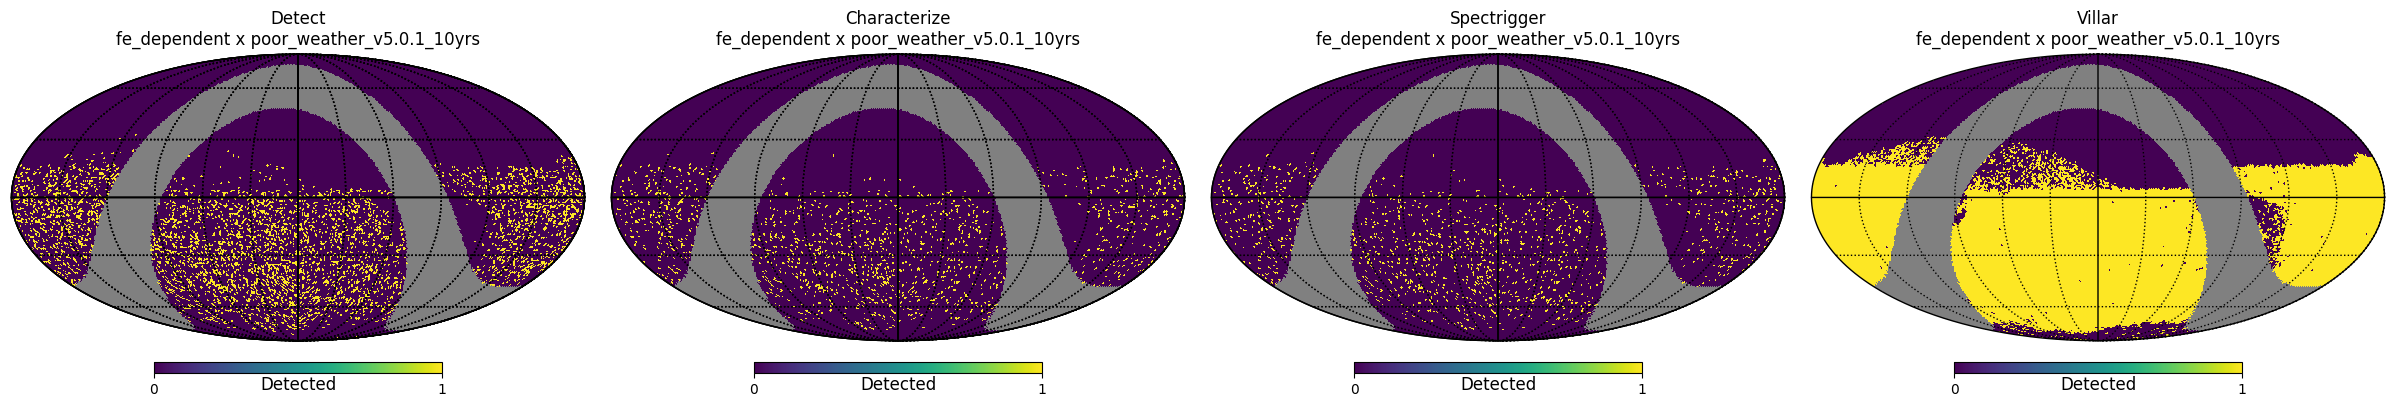

  Saved row: healpix_row_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png

--- o_dependent x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_o_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_villar_o_dependent_baseline_v5.1.1_10yrs_260409.png


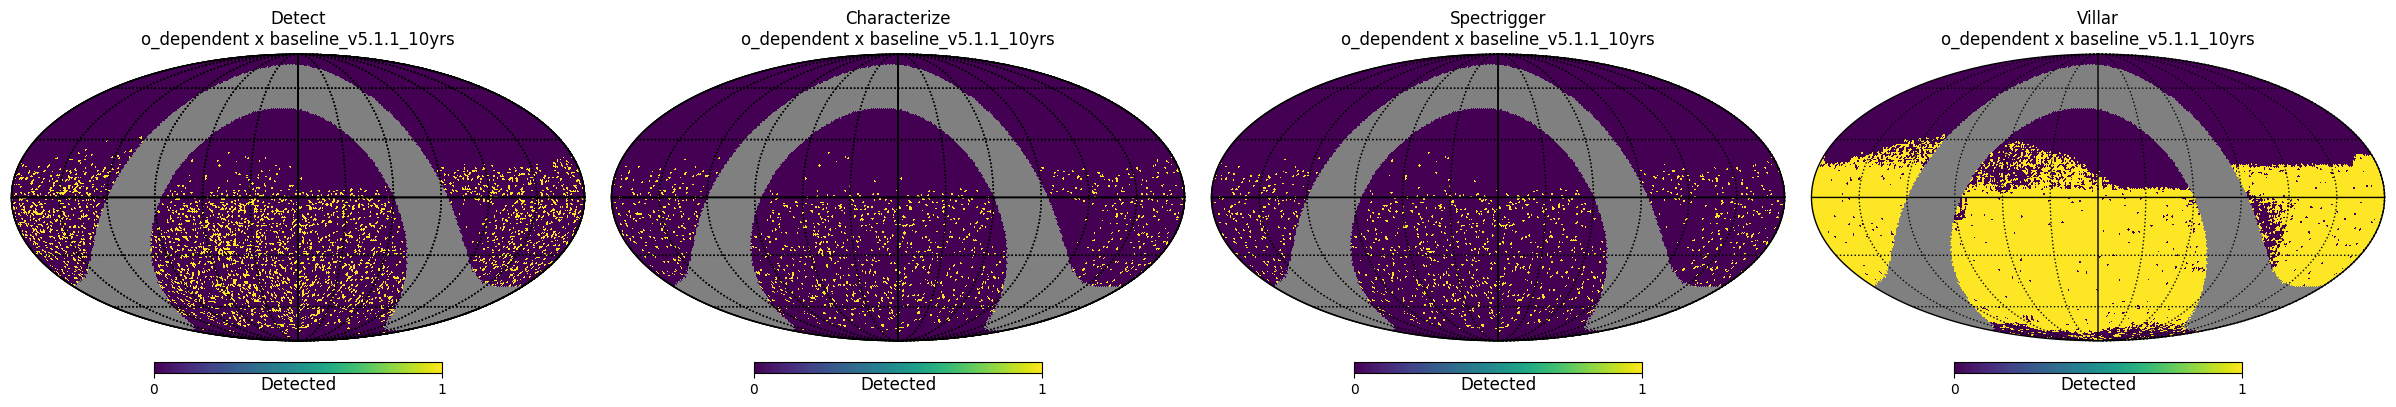

  Saved row: healpix_row_o_dependent_baseline_v5.1.1_10yrs_260409.png

--- o_dependent x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_o_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_o_dependent_four_roll_v5.0.0_10yrs_260409.png


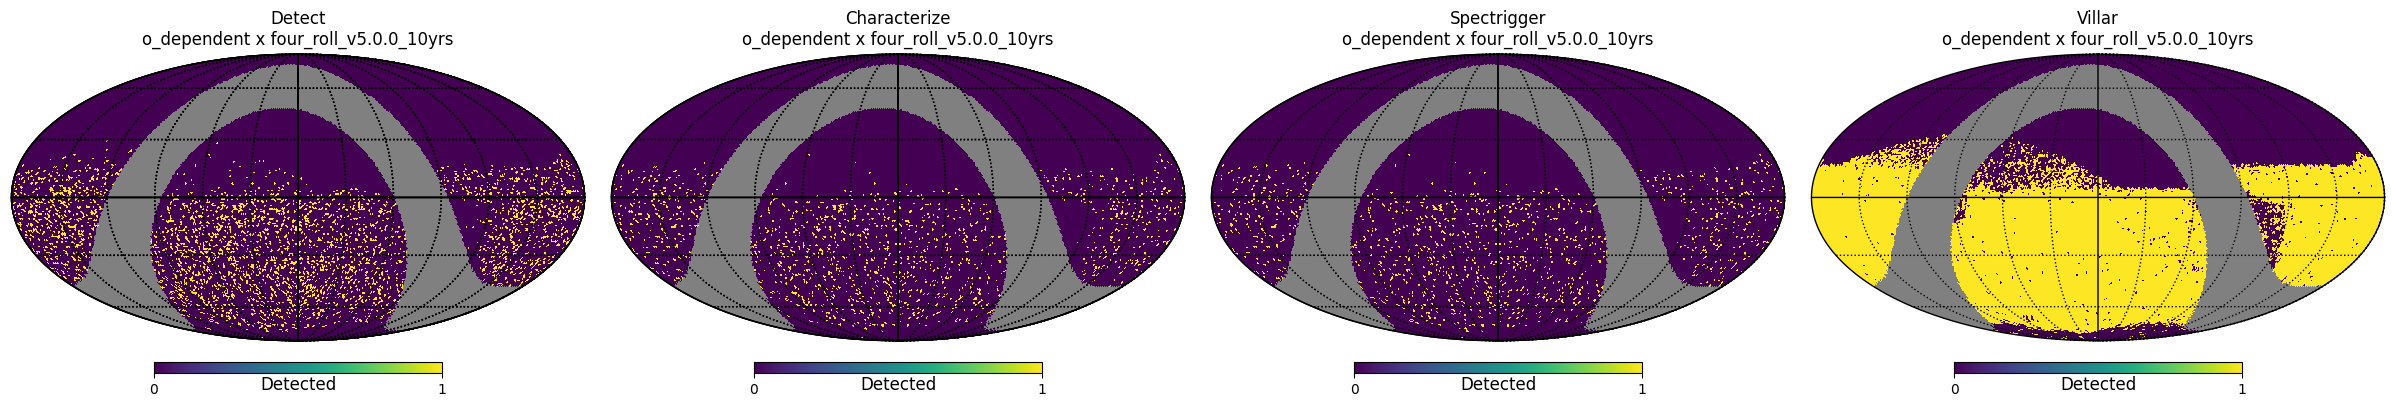

  Saved row: healpix_row_o_dependent_four_roll_v5.0.0_10yrs_260409.png

--- o_dependent x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_o_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_o_dependent_noroll_v5.0.0_10yrs_260409.png


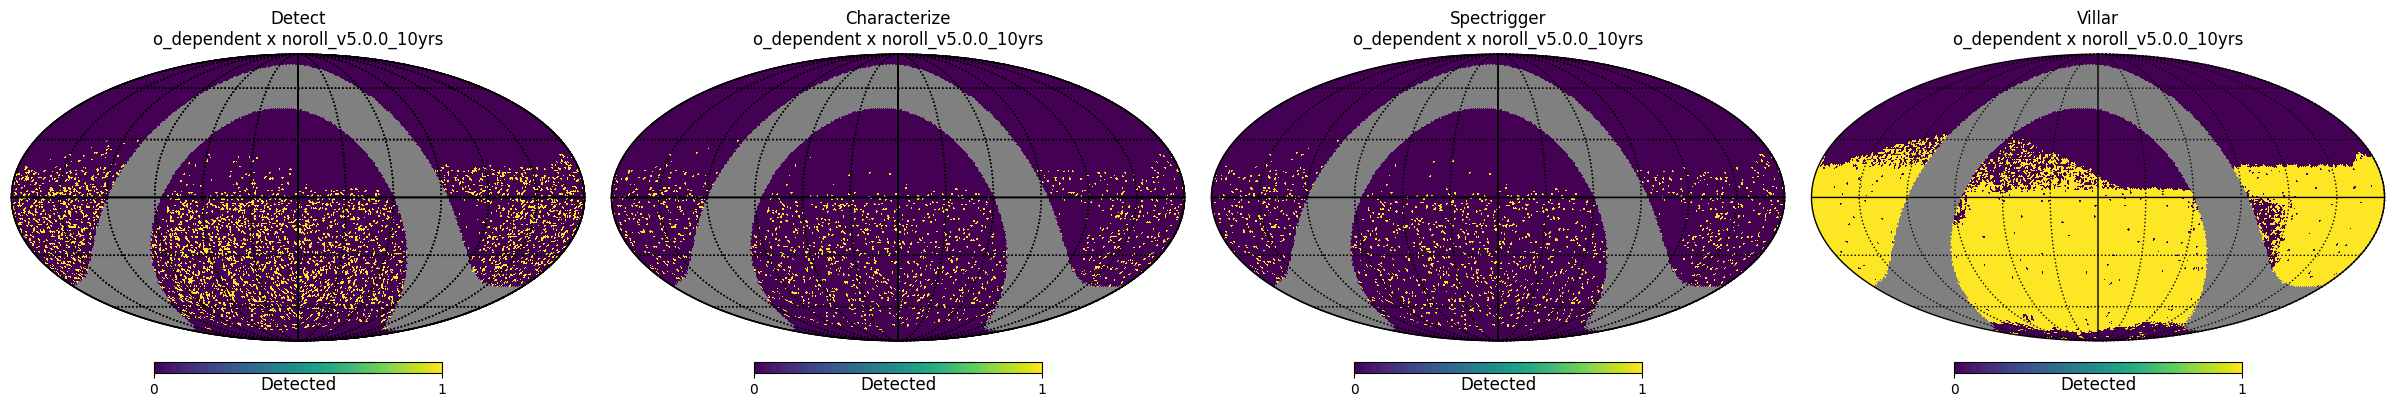

  Saved row: healpix_row_o_dependent_noroll_v5.0.0_10yrs_260409.png

--- o_dependent x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_o_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_villar_o_dependent_poor_weather_v5.0.1_10yrs_260409.png


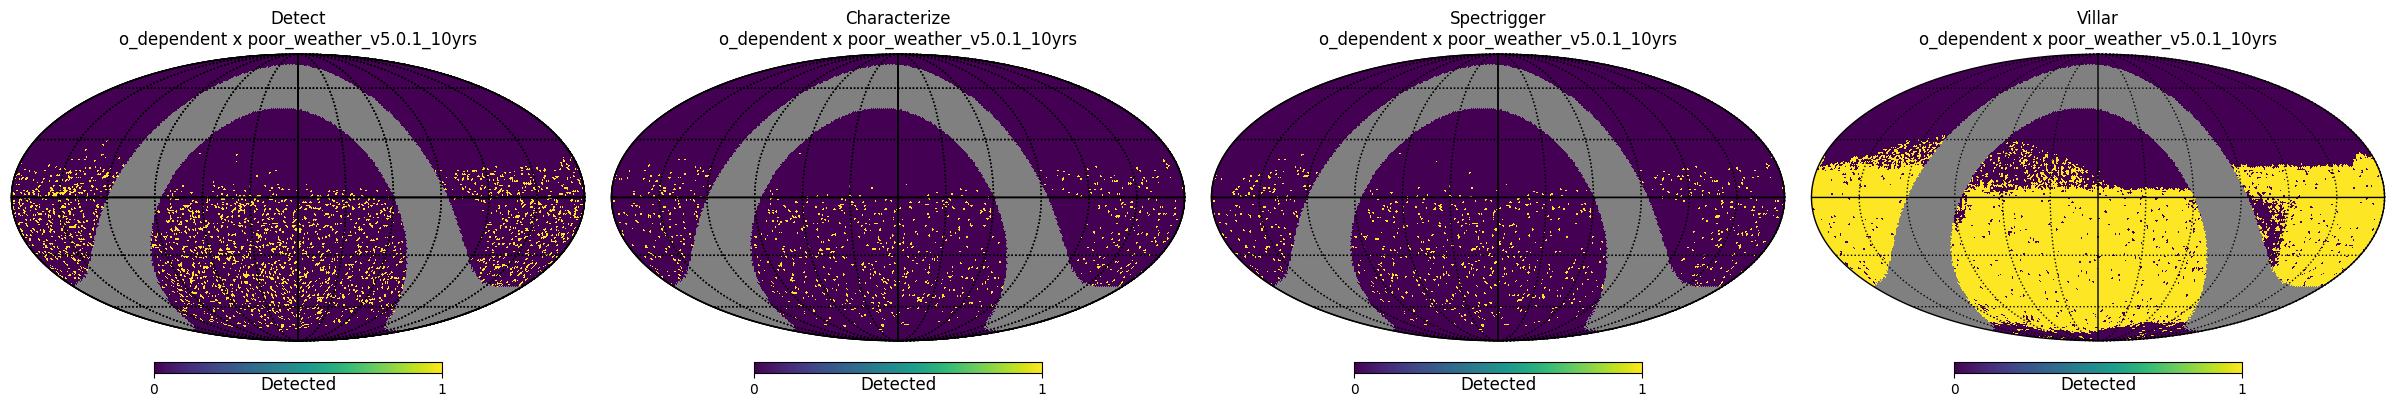

  Saved row: healpix_row_o_dependent_poor_weather_v5.0.1_10yrs_260409.png

--- naive x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_naive_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_characterize_naive_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_spectrigger_naive_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_villar_naive_baseline_v5.1.1_10yrs_260409.png


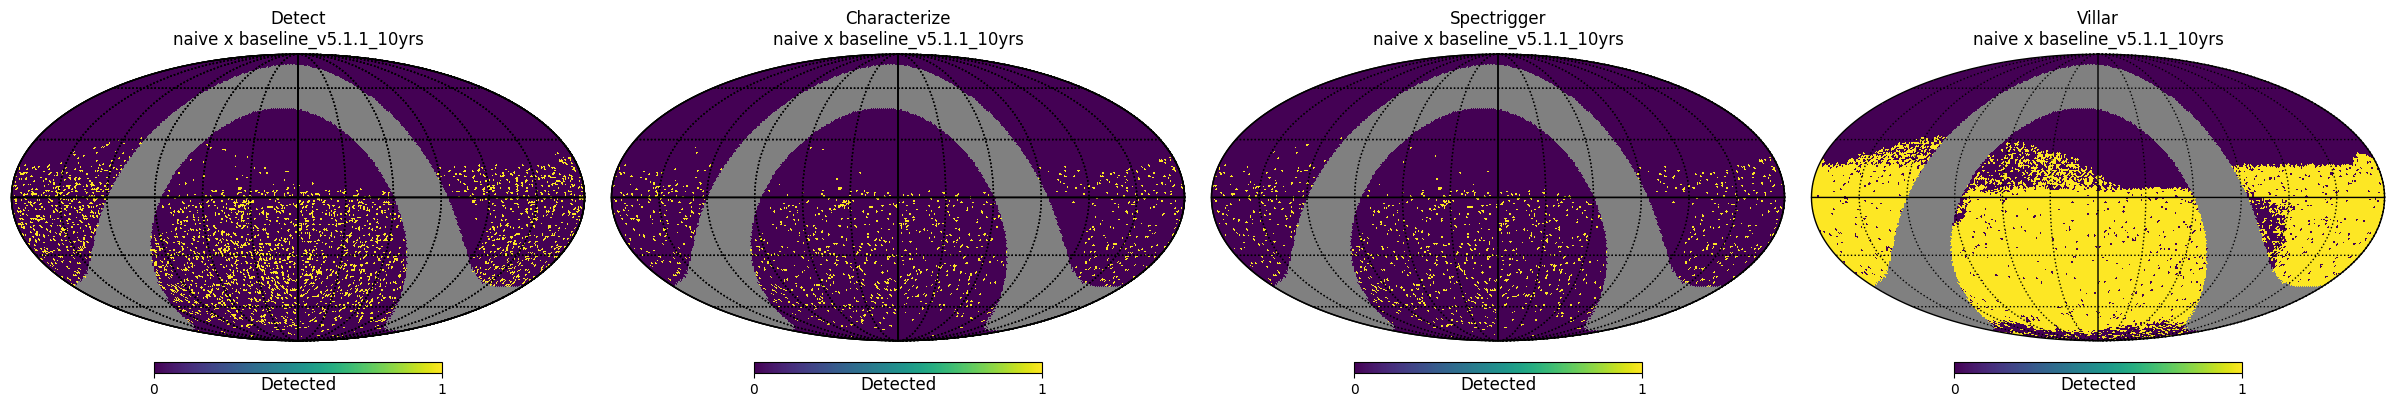

  Saved row: healpix_row_naive_baseline_v5.1.1_10yrs_260409.png

--- naive x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_naive_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_naive_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_naive_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_naive_four_roll_v5.0.0_10yrs_260409.png


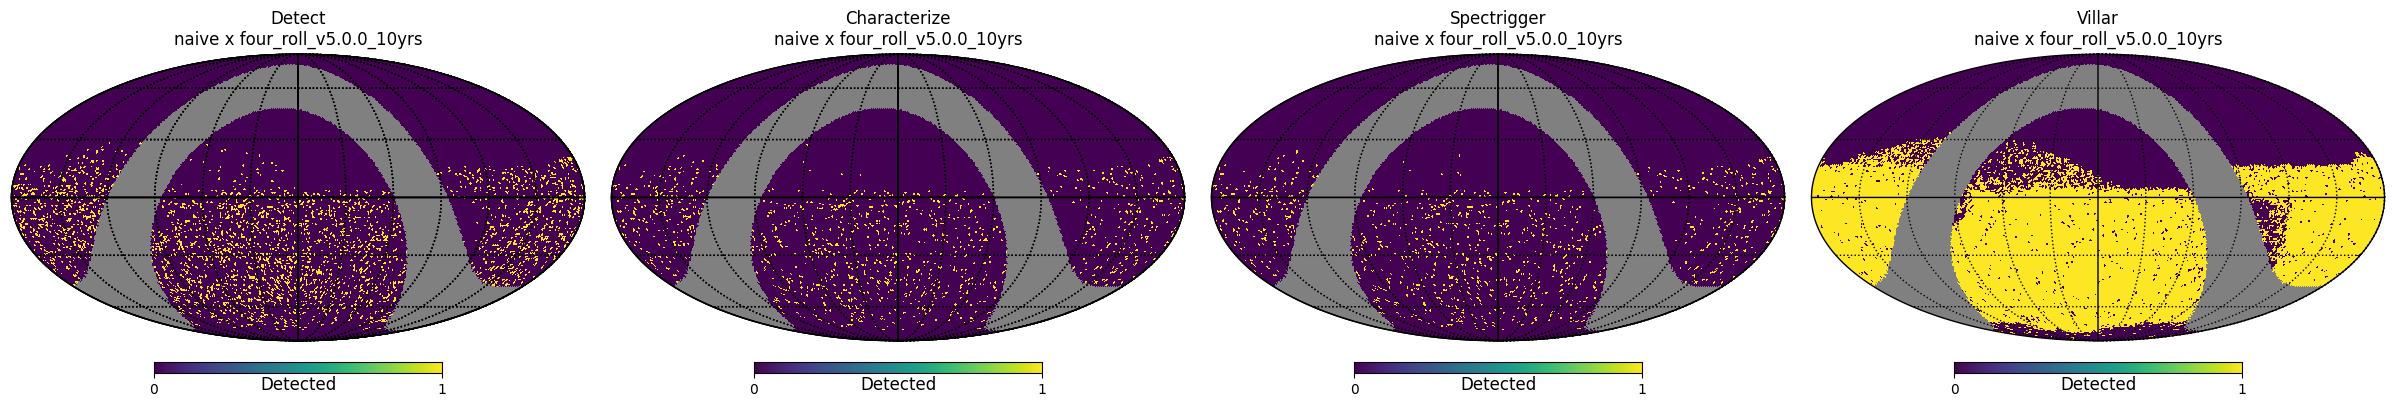

  Saved row: healpix_row_naive_four_roll_v5.0.0_10yrs_260409.png

--- naive x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_naive_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_naive_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_naive_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_naive_noroll_v5.0.0_10yrs_260409.png


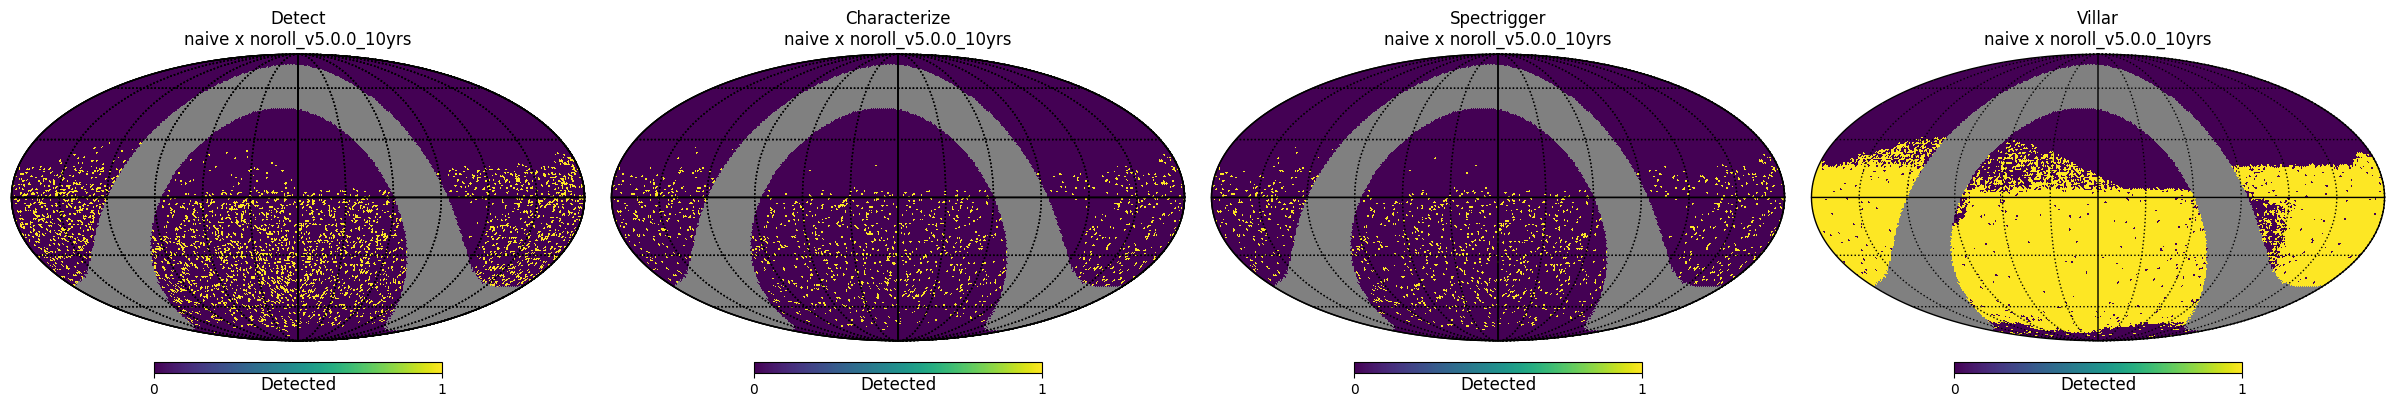

  Saved row: healpix_row_naive_noroll_v5.0.0_10yrs_260409.png

--- naive x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_naive_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_characterize_naive_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_spectrigger_naive_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_villar_naive_poor_weather_v5.0.1_10yrs_260409.png


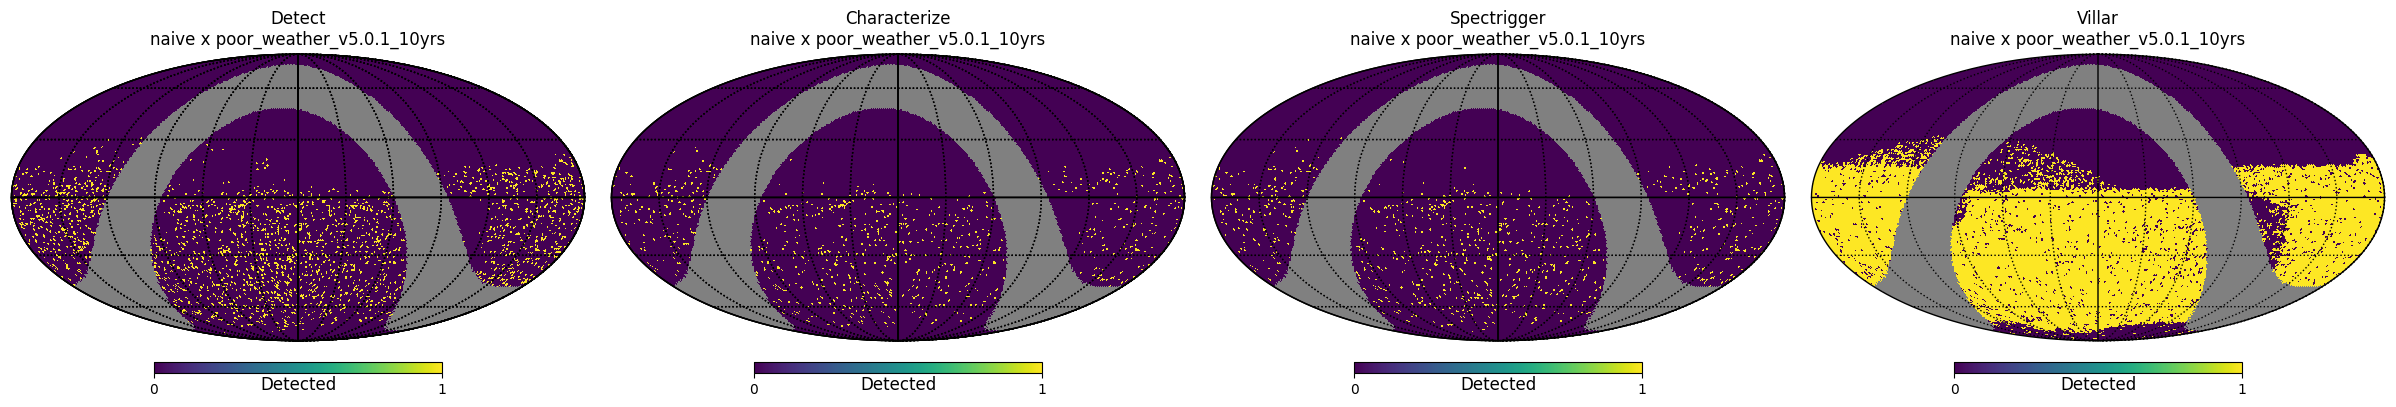

  Saved row: healpix_row_naive_poor_weather_v5.0.1_10yrs_260409.png


In [12]:
# ============================================================================
# CELL 9: HEALPix sky maps — all 3 models × all 4 cadences
# Each cadence = one row of 4 maps (detect, characterize, spectrigger, villar)
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_healpix_efficiency

METRIC_KEYS = ["detect", "characterize", "spectrigger", "villar"]
HEALPIX_FIGSIZE = (24, 4)  # ← width × height per cadence row

for model in MODELS:
    ra_map  = pop_data[model]["ra"]
    dec_map = pop_data[model]["dec"]

    for cadence in CADENCES:
        print(f"\n--- {model} x {cadence} ---")

        # One figure per cadence, 4 subplots side by side
        fig = plt.figure(figsize=HEALPIX_FIGSIZE)

        for col_idx, metric in enumerate(METRIC_KEYS):
            metric_map = pop_data[model][metric][cadence]
            if metric_map is None:
                print(f"  Skipping {metric} — array missing")
                continue

            # Build healpix map
            import healpy as hp
            npix = hp.nside2npix(64)
            injected_map = np.zeros(npix)
            detected_map = np.zeros(npix)
            theta = 0.5 * np.pi - dec_map
            pix   = hp.ang2pix(64, theta, ra_map)
            for i, p in enumerate(pix):
                injected_map[p] += 1
                if int(metric_map[i]) == 1:
                    detected_map[p] += 1
            eff = np.full(npix, hp.UNSEEN)
            mask = injected_map > 0
            eff[mask] = (detected_map[mask] > 0).astype(float)

            # Plot into subplot
            hp.mollview(
                eff,
                title  = f"{metric.capitalize()}\n{model} x {cadence}",
                unit   = 'Detected',
                cmap   = 'viridis',
                min    = 0, max = 1,
                hold   = False,
                sub    = (1, len(METRIC_KEYS), col_idx + 1),
                fig    = fig.number
            )
            hp.graticule()

            # Save individual file too
            out_healpix = get_output_dir("SLSNe", subdir=model) / \
                          f"healpix_{metric}_{model}_{cadence}_{DATE_TAG}.png"
            print(f"  Saved: {out_healpix.name}")

        # Save the combined row figure
        out_row = get_output_dir("SLSNe", subdir=model) / \
                  f"healpix_row_{model}_{cadence}_{DATE_TAG}.png"
        plt.savefig(str(out_row), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"  Saved row: {out_row.name}")

In [ ]:
# ============================================================================
# CELL 10 - MC: Monte Carlo rate uncertainty — all cadences, all models
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO — peak_time already in pop_data from Cell 6
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggle METRIC_KEY to switch which detection stage is plotted.
# Produces one figure per cadence, each with:
#   Top    : N(SLSNe) — all 3 models with 68% CI bands
#   Bottom : Significance — fe vs naive, o vs naive, fe vs o
# ============================================================================

import slsn_metrics.diagnostics as diag_mod
from importlib import reload
reload(diag_mod)
from slsn_metrics.diagnostics import plot_mc_rate_uncertainty_panel

# --- Toggle this to switch metric ---
METRIC_KEY   = 'detect'        # options: 'detect', 'characterize', 'spectrigger'
                               # Note: 'villar' and 'elasticc' are not appropriate here —
                               # they encode photometric classifier scores, not detection
                               # counts, and cannot be interpreted as absolute rates.
METRIC_LABEL = {
    'detect':       'Detections',
    'characterize': 'Characterized',
    'spectrigger':  'Spec Triggers',
}[METRIC_KEY]

SAVE_DIR = get_output_dir('SLSNe', subdir=MODELS[0])

for cadence in CADENCES:
    print(f'\n=== {cadence} | {METRIC_KEY} ===')
    plot_mc_rate_uncertainty_panel(
        pop_data       = pop_data,
        cadence        = cadence,
        metric_key     = METRIC_KEY,
        metric_label   = METRIC_LABEL,
        R_ref_nominal  = 35.0,
        n_realizations = 1000,
        seed           = 42,
        save_dir       = SAVE_DIR,
    )